In [1]:
!pip install -U deepxde numpy scipy matplotlib

In [2]:
import deepxde as dde
import numpy as np
from deepxde.backend import tf
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


In [3]:
# Model parameters
mu_m = 0.5 # Maximum growth rate, 1/h
k_s = 0.1 # Half-saturation constant, g/L
d = 0.2 # Dilution rate, 1/h
s_in = 1.0 # Inlet substrate concentration, g/L
alpha = 0.5 # Economic coefficient (biomass yield)
x0 = 0.05 # Initial biomass, g/L
s0 = 0.8 # Initial substrate, g/L

# Time domain
t_start = 0.0
t_end = 20.0
timedomain = dde.geometry.TimeDomain(t_start, t_end)

In [4]:
# Reference solution using solve_ivp
def ode_system_ivp_norm(t, z):
    X, S = z
    mu = mu_m * S / (k_s + S)
    dX = mu * X - d * X
    dS = d * s_in - alpha * mu * X - d * S
    return [dX, dS]

sol_ivp = solve_ivp(
    ode_system_ivp_norm,[t_start, t_end], [x0, s0],
    t_eval=np.linspace(t_start, t_end, 300), method='Radau'
)

# Converting output arrays to column format using reshape(-1, 1)
t_ref = sol_ivp.t.reshape(-1, 1)
X_ref = sol_ivp.y[0].reshape(-1, 1)
S_ref = sol_ivp.y[1].reshape(-1, 1)

# A function for generating responses at any time point
# Required for the 'solution' argument in the DeepXDE configuration
def reference_solution(t):
    X_interp = np.interp(t[:, 0], t_ref[:, 0], X_ref[:, 0])
    S_interp = np.interp(t[:, 0], t_ref[:, 0], S_ref[:, 0])
    return np.column_stack((X_interp, S_interp))

In [5]:
# This function specifies the physical loss (ODE residual),
# which the neural network will try to reduce to zero
def ode_system(t, y):
    # 't' is the neural network input (time), a tensor of size (N, 1)
    # 'y' is the neural network output, a tensor of size (N, 2), where the first column is X, the second is S
    x = y[:, 0:1]   # Biomass (prediction)
    s = y[:, 1:2]   # Substrate (prediction)

    # dde.grad.jacobian(y, t, i=0) calculates derivative of i-th output with respect to the input t
    dx_dt = dde.grad.jacobian(y, t, i=0)
    ds_dt = dde.grad.jacobian(y, t, i=1)

    # Note:
    # Classic equation: dx_dt = (mu_m * s / (k_s + s)) * x - d * x
    # If the neural network accidentally outputs s = -0.1, then the denominator (k_s + s) will become 0 -> Error and stalling of training
    # Therefore, we mathematically multiply both sides by the denominator (k_s + s)

    # The neural network will be penalized if eq1 and eq2 are not equal to zero, so it will try to minimize them

    # Residual of eq1 - biomass
    eq1 = dx_dt * (k_s + s) - (mu_m * s * x - d * x * (k_s + s))

    # Residual of eq2 - substrate
    eq2 = ds_dt * (k_s + s) - (d * s_in * (k_s + s) - alpha * mu_m * s * x - d * s * (k_s + s))

    return [eq1, eq2]

In [6]:
def normalize_output(t, y):
    # 'y' is a nn input before transformation
    x_net = y[:, 0:1]
    s_net = y[:, 1:2]

    # y_true = initial_condition + t * nn_output
    # If t = 0, (0 * nn_output) = 0
    # If t > 0, nn can change the answer to fit ODE
    x_true = x0 + t * x_net
    s_true = s0 + t * s_net

    # Creating tensor (N, 2)
    return tf.concat([x_true, s_true], axis=1)

In [7]:
# Preparing data
data = dde.data.PDE(
    geometry=timedomain,           # Time
    pde=ode_system,                # ODE System
    bcs=[],                        # Initial condition is provided in normalize_output
    num_domain=50,                # Collocation points amount (generated in [0, 20] time domain)
    solution=reference_solution,   # Reference solution
    num_test=300                   # Validation points amount
)

In [8]:
# Network architecture
layer_size = [1] + [30] * 2 + [2]   # 1 input, 2 hidden layers with 30 neurons in each, 2 outputs
activation = "tanh"                 # Activation function
initializer = "Glorot uniform"      # Random weight initialization method
net = dde.nn.FNN(layer_size, activation, initializer)

# Applying initial condition
net.apply_output_transform(normalize_output)

# Creating the model
model = dde.Model(data, net)
model.compile("adam", lr=0.0001,
              loss="MSE",
              metrics=["l2 relative error"])

Compiling model...
'compile' took 0.034801 s



In [9]:
# Model train
losshistory, train_state = model.train(iterations=40000)

Training model...

Step      Train loss              Test loss               Test metric   
0         [4.12e+00, 3.25e+00]    [4.13e+00, 3.23e+00]    [8.38e+00]    
1000      [9.51e-03, 6.52e-03]    [8.85e-03, 5.72e-03]    [2.10e+00]    
2000      [2.92e-03, 4.63e-03]    [2.71e-03, 4.08e-03]    [8.50e-01]    
3000      [1.83e-03, 3.16e-03]    [1.66e-03, 3.00e-03]    [9.74e-01]    
4000      [1.43e-03, 1.87e-03]    [1.33e-03, 1.92e-03]    [9.02e-01]    
5000      [9.71e-04, 1.04e-03]    [9.35e-04, 1.08e-03]    [7.93e-01]    
6000      [6.87e-04, 3.16e-04]    [6.75e-04, 3.24e-04]    [4.30e-01]    
7000      [3.99e-04, 1.87e-04]    [3.92e-04, 1.79e-04]    [3.52e-01]    
8000      [2.75e-04, 1.87e-04]    [2.63e-04, 1.76e-04]    [3.16e-01]    
9000      [1.99e-04, 1.47e-04]    [1.86e-04, 1.38e-04]    [2.71e-01]    
10000     [1.25e-04, 1.13e-04]    [1.19e-04, 1.14e-04]    [1.80e-01]    
11000     [9.72e-05, 8.94e-05]    [9.45e-05, 9.46e-05]    [1.54e-01]    
12000     [8.29e-05, 6.61e-05]  

In [10]:
print("Best train loss after Adam:", train_state.best_loss_train)
print("Best test loss after Adam:", train_state.best_loss_test)

Best train loss after Adam: 5.9339334e-05
Best test loss after Adam: 7.1415874e-05


In [11]:
# L-BFGS optimizer
model.compile("L-BFGS",
              loss="MSE",
              metrics=["l2 relative error"])

Compiling model...
'compile' took 0.006023 s



In [12]:
# Дообучение
losshistory, train_state = model.train()

Training model...

Step      Train loss              Test loss               Test metric   
40000     [3.78e-05, 2.16e-05]    [4.46e-05, 2.68e-05]    [3.94e-02]    
40032     [3.72e-05, 2.10e-05]    [4.33e-05, 2.61e-05]    [4.07e-02]    

Best model at step 40032:
  train loss: 5.82e-05
  test loss: 6.94e-05
  test metric: [4.07e-02]

'train' took 13.500115 s



In [13]:
print("Best train loss after L-BFGS:", train_state.best_loss_train)
print("Best test loss after L-BFGS:", train_state.best_loss_test)

Best train loss after L-BFGS: 5.8195044e-05
Best test loss after L-BFGS: 6.94074e-05


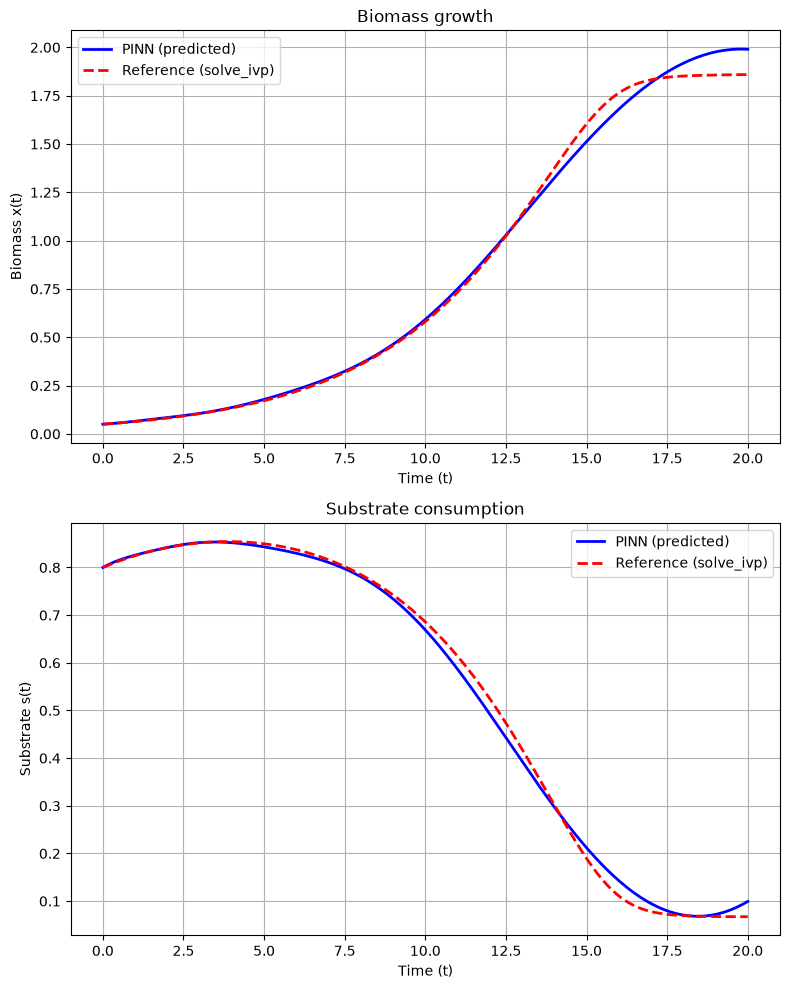

In [14]:
# Visuals
t_plot = np.linspace(t_start, t_end, 300).reshape(-1, 1)

y_pred = model.predict(t_plot)
x_pred = y_pred[:, 0]
s_pred = y_pred[:, 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

ax1.plot(t_plot, x_pred, 'b-', label='PINN (predicted)', linewidth=2)
ax1.plot(t_ref, X_ref, 'r--', label='Reference (solve_ivp)', linewidth=2)
ax1.set_xlabel('Time (t)')
ax1.set_ylabel('Biomass x(t)')
ax1.set_title('Biomass growth')
ax1.legend()
ax1.grid(True)

ax2.plot(t_plot, s_pred, 'b-', label='PINN (predicted)', linewidth=2)
ax2.plot(t_ref, S_ref, 'r--', label='Reference (solve_ivp)', linewidth=2)
ax2.set_xlabel('Time (t)')
ax2.set_ylabel('Substrate s(t)')
ax2.set_title('Substrate consumption')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


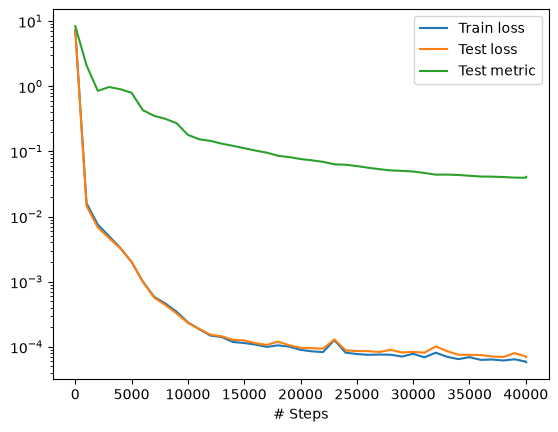

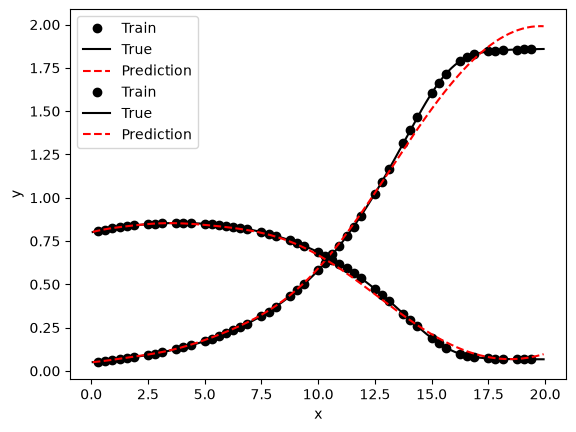

In [15]:
# Built-in function of DeepXDE for saving loss history (Loss function over epochs)
# isplot=True will show a separate plot
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

In [16]:
model.save('model.h5')

'model.h5-40032.weights.h5'